In [2]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [3]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from datetime import datetime
# import NSMap as ns
from matplotlib.patches import ConnectionPatch
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors

import src.NonstationarityTest as nt
import src.NSHyperparameterEstimation as nhe
import src.NSMap as ns

# Analysis of Newport Line Dataset

Here we assess the nonstationarity of time series of several species of plankton which were subject to an extreme heatwave event in 2014-2016. Measurements were taken very irregularly, so instead of using the raw time series, we average all observations taken within a given month. Only a handful of months had no observations - these were left as null.

In [4]:
# these are the most abundant species from the Newport dataset for which complete data are available.
top_4_species = ['PSEUDOCALANUS', 'OIKOPLEURA', 'ACARTIA LONGIREMIS', 'CENTROPAGES'] # 'PARACALANUS PARVUS']

filename = "../../datasets/newport_aggregated_series.csv"
# Read as float32, skip first row if it's a header
df = pd.read_csv(filename, encoding="utf-8", dtype=np.float32)
table = df.to_numpy(dtype=np.float32)

# create a dictionary which maps each species name to its respective time series
species_dict = dict()
for i, species in enumerate(top_4_species):
    species_dict[species] = table[:,i]

In [5]:
maxLen = table.shape[0]

lengths = np.arange(24, maxLen+1,step=12)

In [40]:
tx = np.linspace(0, 1, maxLen)
Xemb, Y, t = ns.delayEmbed(table[:,i], 3, 1, t=tx)

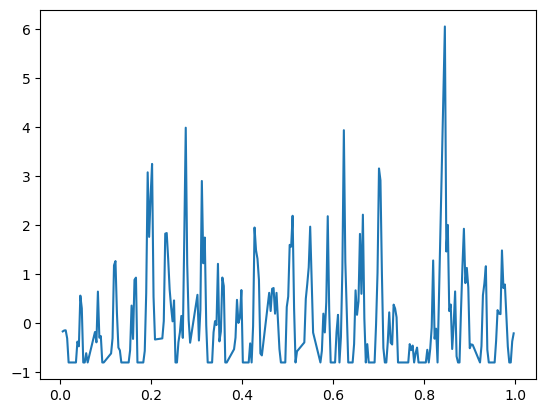

In [41]:
plt.plot(t, Xemb[:, 0])

In [35]:
table[:, 0].shape

(312,)

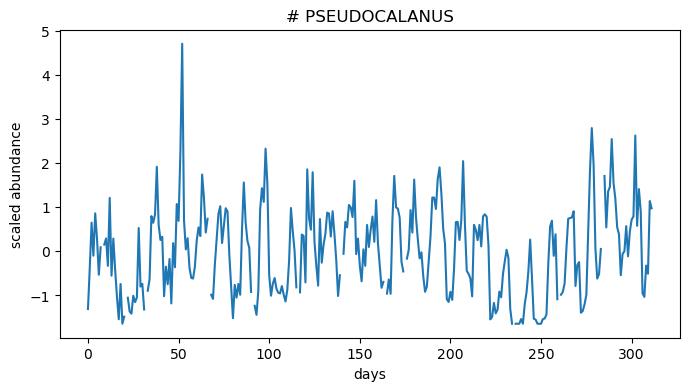

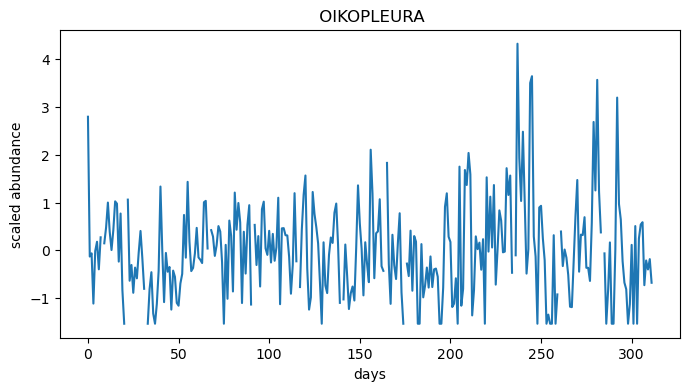

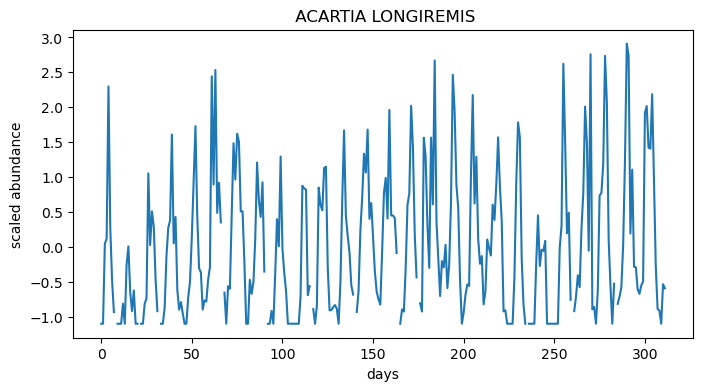

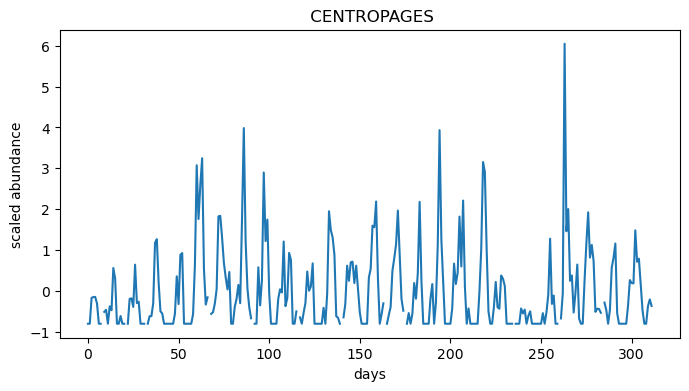

In [5]:
for i in range(4):
    fig, ax = plt.subplots(1,figsize=(8,4))
    ax.set_title(df.columns[i])
    ax.plot(table[:,i])
    ax.set_ylabel("scaled abundance")
    ax.set_xlabel("days")
    plt.show()

# Tau Determination

In [34]:
ns.delayEmbed(ts, 3, 1)

array([-1.30817346e+00, -3.72069378e-01,  6.50815102e-01, -9.93479256e-02,
        8.61895021e-01,  2.82550853e-01, -5.31421907e-01,  9.09398868e-02,
                   nan,  1.53672329e-01,  2.91768888e-01, -3.29258940e-01,
        1.21109449e+00, -5.52100133e-01,  2.88971098e-01, -4.11096459e-01,
       -1.03246650e+00, -1.54038124e+00, -7.39873961e-01, -1.64144104e+00,
       -1.48170124e+00,             nan, -1.05158002e+00, -1.36391505e+00,
       -1.41402137e+00, -1.00686797e+00, -1.15275704e+00, -1.04736858e+00,
        5.29208049e-01, -8.00112605e-01, -7.37596451e-01, -1.31961207e+00,
                   nan, -8.93901109e-01, -6.34130615e-01,  7.97210230e-01,
        6.46677581e-01,  8.36944044e-01,  1.91684605e+00,  6.01862888e-01,
        2.57279871e-01,  3.29466720e-01, -1.01795449e+00, -3.48703674e-01,
       -7.47190284e-01, -1.73156691e-01, -1.18083147e+00,  1.86004557e-01,
       -3.61748275e-01,  1.07265895e+00,  6.90090961e-01,  2.24892503e+00,
        4.70623809e+00,  

In [7]:
h = 0
E_max = 6
taus = np.arange(1,7)
r_sqrd_table = np.zeros((len(taus), 4))

for i, species in enumerate(top_4_species):
    ts = species_dict[species]

    r_sqrds = [ns.get_delta_agg(ts, E_max, tau=tau,
                             return_forecast_skill=True)[2] 
                   for tau in taus]
    r_sqrd_table[:, i] = r_sqrds

np.savetxt("../results/newport_multiwindow/newport_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")

NameError: name 'ns' is not defined

In [10]:
# or don't rerun the above block and just use these precomputed values
r_sqrd_table = np.loadtxt("../results/newport_multiwindow/newport_rsqrd_vs_tau.csv", delimiter=",")

In [11]:
# Check Autocorrelation
taus = np.arange(1,7)
autocorr_table = np.zeros((len(taus), 4))

for i, species in enumerate(top_4_species):
    ts = species_dict[species]
    ts_no_NA = ts[~np.isnan(ts)]
    autocorr_table[:,i] = np.array([np.corrcoef(ts_no_NA[tau:], ts_no_NA[:-tau])[0,1]
                                      for tau in taus])

In [12]:
r_sqrd_table[:,3]

array([0.42108087, 0.14051321, 0.26925917, 0.11748842, 0.16474065,
       0.07609745])

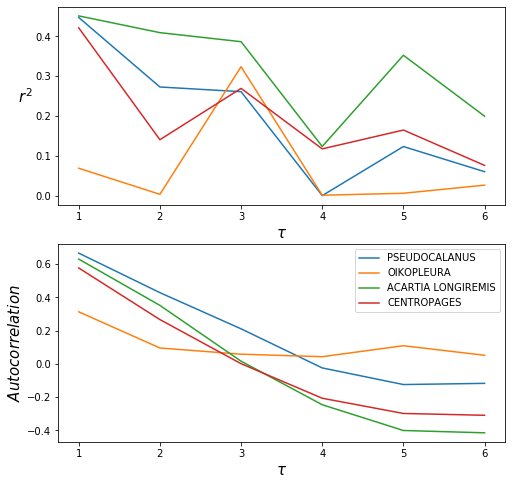

In [13]:
fig, ax = plt.subplots(2, figsize=(8,8))
for i, species_label in enumerate(top_4_species):
    ax[0].plot(taus, r_sqrd_table[:,i], label=species_label)
    ax[1].plot(taus, autocorr_table[:,i], label=species_label)

ax[0].set_ylabel(r"$r^2$", fontsize = 15, rotation = 0, labelpad=10)
ax[0].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)

ax[1].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)
ax[1].set_ylabel(r"$Auto correlation$", fontsize = 15, rotation = 90)

plt.legend()

Final choice is tau = 3 across all series as autocorrelations diminishes for all series while retaining solid forecast skill across the board. Note that the strongly negative autocorrelation for Paracalanus Parvus at high lags is as bad as positive autocorrelation.

In [8]:
import json

# Load parameters from JSON file
def load_params(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

params = load_params("newport_params.json")

In [9]:
E_range = [0, 50] # params["E_range"]
lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]
N_replicates = params["N_replicates"]
resolution = params["resolution"]
theta_range = (0, 100) # params["theta_range"]
delta_range = (0, 100) # params["delta_range"]

In [10]:
length = int(lengths[-5].item())
start = 0

tau = 1

ts = table[:, 0]

ts_chunk = ts[start:length+start]
t = np.linspace(0, 1, length)

data = (ts_chunk, t, tau)

In [188]:
theta, delta = nhe.compute_posterior_weighted_parameters(data, theta_range, delta_range, E_range, lambda1, lambda2, p, resolution=5)
print(theta, delta)

1.7239629422750197e-21 1.0380313503462114e-17


In [189]:
Xr, tx, tau = data

theta_values = np.linspace(theta_range[0], theta_range[1], 4)
delta_values = np.linspace(delta_range[0], delta_range[1], 4)

# Build log-likelihood grid over all E, theta, delta
log_likelihoods, E_vals, theta_vals, delta_vals = nt._build_log_likelihood_grid(
    Xr, tx, E_range, theta_values, delta_values, tau)

In [208]:
Xemb, tx = ns.delayEmbed(Xr, 24, 4)

In [209]:
tx.shape

(78, 1)

In [210]:
Xemb.shape

(78, 24)

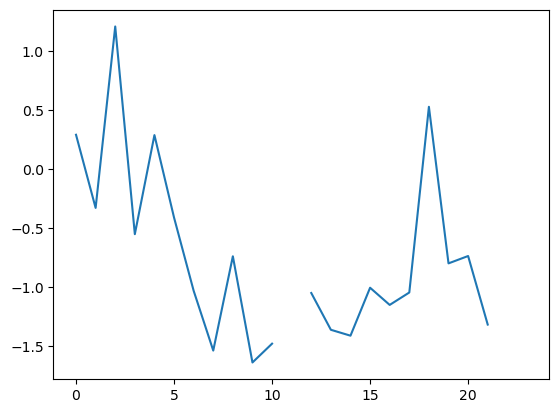

In [200]:
plt.plot(Xr[10:10+24])

In [195]:
# Build prior grid: shape (len(E_vals), len(theta_vals), len(delta_vals))
prior_E_vals = np.array([nt.prior_E(E, p) for E in E_vals])
prior_theta_vals = np.array([nt.prior_1d(th, lambda1) for th in theta_vals])
prior_delta_vals = np.array([nt.prior_1d(dl, lambda2) for dl in delta_vals])
prior_grid = prior_E_vals[:, None, None] * prior_theta_vals[None, :, None] * prior_delta_vals[None, None, :]

In [196]:
# Normalize log-likelihoods for stability
log_likelihoods = log_likelihoods - np.max(log_likelihoods)

# Compute unnormalized posterior grid
posterior_grid = np.exp(log_likelihoods) * prior_grid

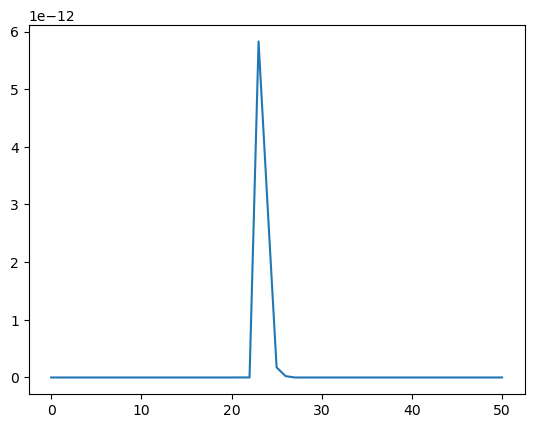

In [197]:
plt.plot(np.sum(posterior_grid, axis=(1,2)))

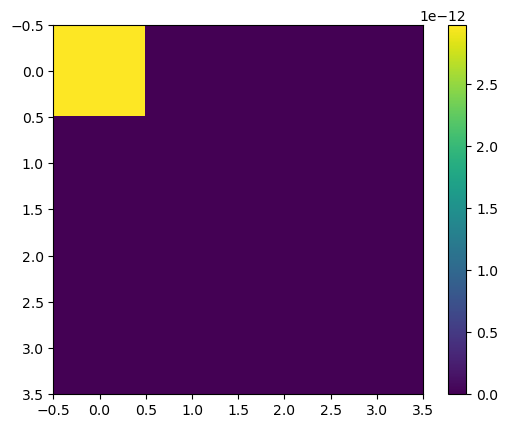

In [186]:
plt.imshow(posterior_grid[24])
plt.colorbar()

# Effect of Time Window on Pseudocalanus
The point of this experiment is to determine the impact of time series window on our assessment of nonstationarity. We conjecture that at intermediate time series lengths we will get the most nonstationarity positives. To test this, we assess nonstationarity for all subsequences of the original time series with length a multiple of 12, and starting index is a multiple of 12.

In [27]:
evidence_to_probability = lambda ev: (10 ** (ev / 10)) / ((10 ** (ev / 10)) + 1)

def drawBracket(start_year, length, ax):
    start_index = start_year - 1996
    length_index = 26 - length
    ax.plot(np.array([start_index, start_index + length ]),
            np.ones(2)*length_index, c="black")
    
# Convert the delta values for each subseries into a square matrix
# which is plotted using matplotlib's imshow.
def makeHeatMapNewport(results):
    nonstationarityHeatMap = np.zeros((25,25)) * np.nan
    for l, o, e, p, t, d in results:
        i_length = 24-(int(l/12) - 2)
        i_offset = int(o/12)
        nonstationarityHeatMap[i_length, i_offset] = p # evidence_to_probability(e)
    maskedNonstationarityHeatMap = np.ma.array(nonstationarityHeatMap,
                                               mask=np.isnan(nonstationarityHeatMap))
    return nonstationarityHeatMap

def makeFigureNewport(nonstationarityHeatMap, ts, name, ax):
    name_to_fig_title = {'Oikopleura' : 'Figure_S12',
                         'Acartia longiremis' : 'Figure_S13',
                         # 'Paracalanus parvus' : 'Figure_S14',
                         'Pseudocalanus' : 'Figure_S14',
                         'Centropages' : 'Figure_S15'}
    
    im = ax.imshow(nonstationarityHeatMap[:-3,:], cmap=custom_cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(0,26+1,step=2))
    ax.set_xlim(-1.08,27.7)

    ax.set_ylabel("Time series length (years)",fontsize=15)
    ax.set_yticks(np.arange(0,21+1))
    ax.set_yticklabels(np.flip(np.arange(4,25+1)+1))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = plt.colorbar(im, cax=cax, )
    cb.set_label(r"p(NS)",fontsize=15)

    axTS = divider.append_axes('bottom', size='30%', pad=0.1)

    axTS.plot(np.linspace(1996.264,2022.335,num=312), ts,c="dodgerblue")
    axTS.set_xticks(np.arange(1996,2022+1,step=2))
    axTS.set_yticks([])
    axTS.set_ylabel(name, fontsize= 12, style='italic')
    axTS.set_xlabel("Start year",fontsize=15)

    plt.savefig(f"../../figures_eps/newport_multiwindow/{name_to_fig_title[name]}.eps", format="eps", bbox_inches="tight")

In [28]:
# Compute the nonstationarity of windows of each series. This has
# been precomputed, uncomment to run again to regenerate results.

"""
E_max = 5
tau = 3

for index, species in enumerate(top_4_species):
    ts = species_dict[species]
    
    maxLen = ts.shape[0]
    lengths = np.arange(24,maxLen+1,step=12)

    n_rows = 325
    # length, starting index, delta, theta, r_sqrd
    results = np.zeros((n_rows, 5))
    tally = 0

    for length in lengths:
        for start in np.arange(0, maxLen - length+1, step=12):
            ts_chunk = ts[start:length+start]
            try:
                delta, theta, r_sqrd = ns.get_delta_agg(ts_chunk, E_max-1, tau=tau, return_forecast_skill=True)
            except:
                delta, theta, r_sqrd = (0,0,0)
            delta, theta, r_sqrd = ns.get_delta_agg(ts_chunk, E_max-1, tau=tau, return_forecast_skill=True)
            results[tally] = np.array([length, start, delta, theta, r_sqrd])
            tally += 1

    np.savetxt(f"../results/newport_multiwindow/{species}_time_window.csv",results, fmt="%i,%i,%0.5f,%0.5f,%0.5f")
"""

'\nE_max = 5\ntau = 3\n\nfor index, species in enumerate(top_4_species):\n    ts = species_dict[species]\n\n    maxLen = ts.shape[0]\n    lengths = np.arange(24,maxLen+1,step=12)\n\n    n_rows = 325\n    # length, starting index, delta, theta, r_sqrd\n    results = np.zeros((n_rows, 5))\n    tally = 0\n\n    for length in lengths:\n        for start in np.arange(0, maxLen - length+1, step=12):\n            ts_chunk = ts[start:length+start]\n            try:\n                delta, theta, r_sqrd = ns.get_delta_agg(ts_chunk, E_max-1, tau=tau, return_forecast_skill=True)\n            except:\n                delta, theta, r_sqrd = (0,0,0)\n            delta, theta, r_sqrd = ns.get_delta_agg(ts_chunk, E_max-1, tau=tau, return_forecast_skill=True)\n            results[tally] = np.array([length, start, delta, theta, r_sqrd])\n            tally += 1\n\n    np.savetxt(f"../results/newport_multiwindow/{species}_time_window.csv",results, fmt="%i,%i,%0.5f,%0.5f,%0.5f")\n'

In [29]:
# Create custom color map
orange_rgba = colors.to_rgba("orange")
dodgerblue_rgba = colors.to_rgba("dodgerblue")
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [dodgerblue_rgba, orange_rgba]) 
custom_cmap.set_bad("white", 1)

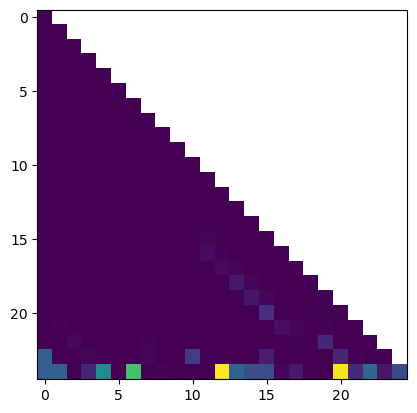

In [30]:
file_name_list = ['# PSEUDOCALANUS',
                  ' OIKOPLEURA',
                  ' ACARTIA LONGIREMIS',
                  ' CENTROPAGES']
index = 0  # Change this index to plot different species

results = np.loadtxt(f"../../results/newport_line_multiwindow_tau_1/{file_name_list[index]}_time_window.csv", delimiter=",")
lengths = np.unique(results[:,0])

ts = species_dict[species]
plt.imshow(nonstationarityHeatMap)

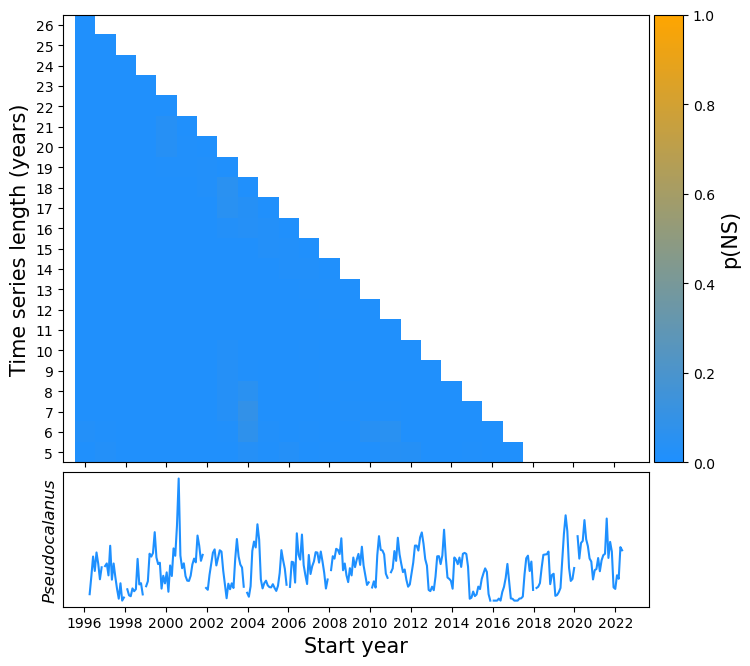

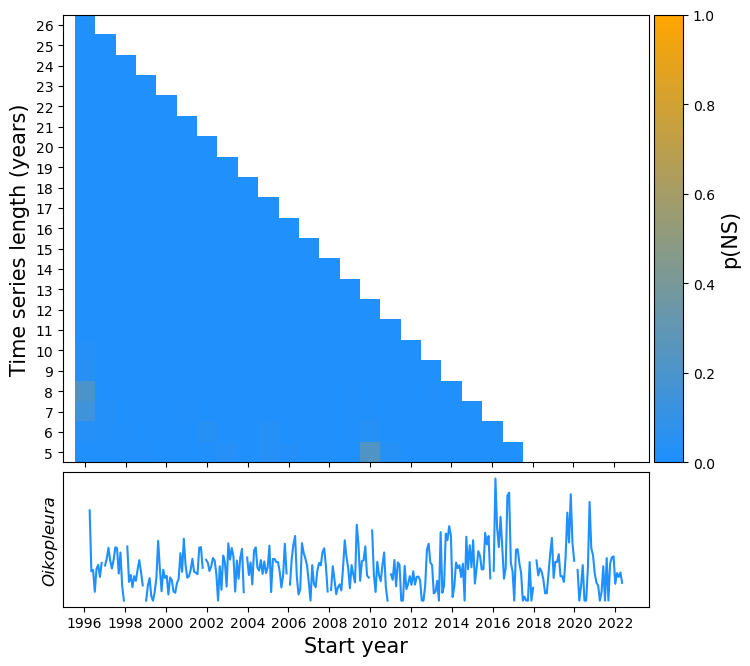

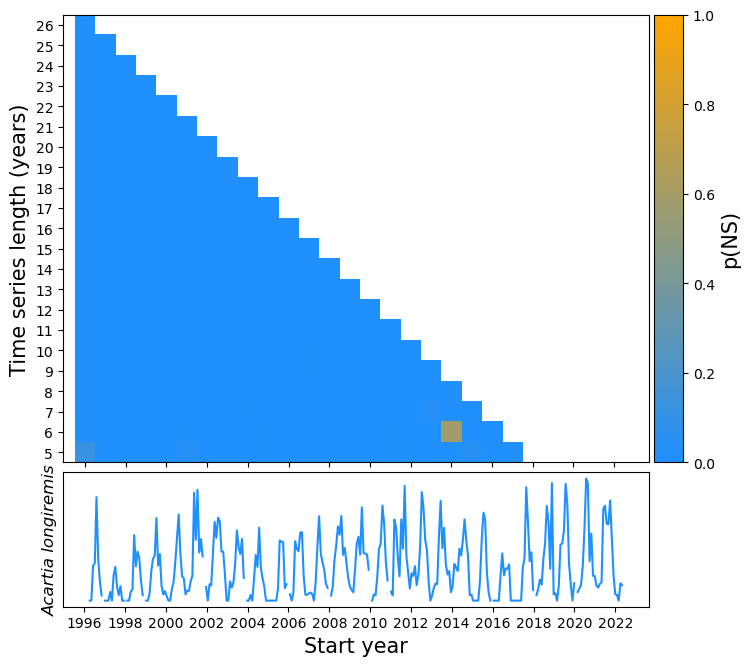

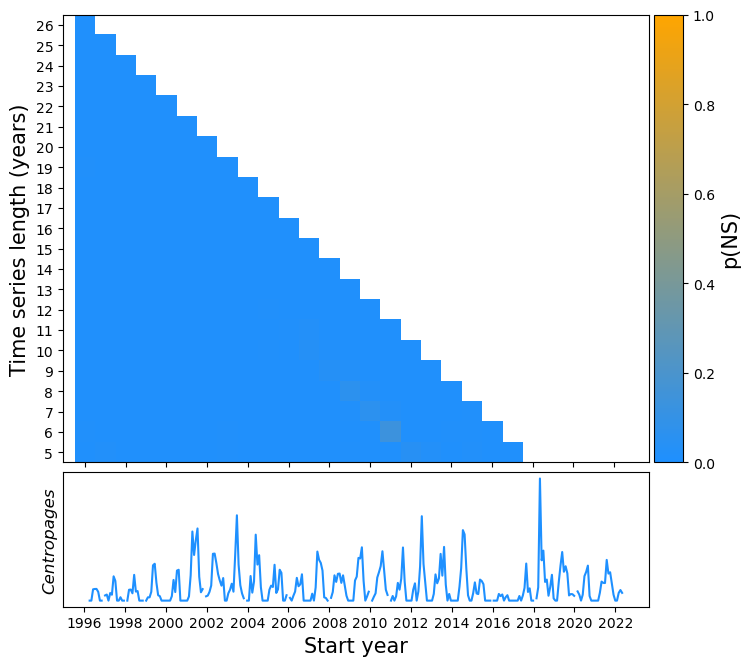

In [31]:
species_list = ['Pseudocalanus', 'Oikopleura', 'Acartia longiremis', 'Centropages']
file_name_list = ['# PSEUDOCALANUS',
                  ' OIKOPLEURA',
                  ' ACARTIA LONGIREMIS',
                  ' CENTROPAGES']

# Produce the plots for each series
for index, species in zip([0, 1, 2, 3], top_4_species):
    fig, ax = plt.subplots(1,figsize=(8,8))
    
    results = np.loadtxt(f"../../results/newport_line_multiwindow_tau_1/{file_name_list[index]}_time_window.csv", delimiter=",")
    lengths = np.unique(results[:,0])
    
    ts = species_dict[species]
    nonstationarityHeatMap = makeHeatMapNewport(results)
    makeFigureNewport(nonstationarityHeatMap, ts, species_list[index], ax)